# AlphaGenome In-Silico Mutagenesis (ISM) Analysis

This notebook analyzes AlphaGenome variant scoring results from saturation mutagenesis experiments.
Optimized for analyzing hundreds of variants across a genomic region.

## Setup
1. Set the `INPUT_PATH` to your CSV file or directory containing AlphaGenome CSV files
2. Set the `OUTPUT_DIR` for saving results
3. Run all cells in order

## 1. Configuration

In [27]:
# ============================================
# CONFIGURATION - MODIFY THESE PATHS
# ============================================

# Input: Single CSV file or directory with multiple alphagenome_scores_*.csv files
INPUT_PATH = "./alphagenome_ISM_COL4A5_intron6/"  # Directory or single file
OUTPUT_DIR = "./alphagenome_ISM_COL4A5_intron6/"  # Directory for output files

# Pathogenicity thresholds (can be customized)
THRESHOLD_HIGH = 0.999      # Top 0.1%
THRESHOLD_MODERATE = 0.99   # Top 1%
THRESHOLD_LOW = 0.95        # Top 5%

# Number of top variants to display in tables
TOP_N_VARIANTS = 20

## 2. Import Libraries

In [28]:
import glob
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

# Create output directory if needed
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Input path: {INPUT_PATH}")
print(f"Output directory: {OUTPUT_DIR}")

Input path: ./alphagenome_ISM_COL4A5_intron6/
Output directory: ./alphagenome_ISM_COL4A5_intron6/


## 3. Data Loading Function

In [29]:
def load_alphagenome_data(input_path: str) -> pd.DataFrame:
    """
    Load AlphaGenome data from either a single CSV file or a directory of CSV files.
    Optimized for large numbers of files.
    """
    input_path = Path(input_path)
    
    if input_path.is_file():
        print(f"Loading single file: {input_path.name}")
        combined_df = pd.read_csv(input_path)
    elif input_path.is_dir():
        file_pattern = str(input_path / 'alphagenome_scores_*.csv')
        files = glob.glob(file_pattern)
        
        if not files:
            file_pattern = str(input_path / '*.csv')
            files = glob.glob(file_pattern)
        
        if not files:
            raise FileNotFoundError(f"No CSV files found in {input_path}")
        
        print(f"Found {len(files)} CSV files")
        print(f"Loading files (this may take a moment for large datasets)...")
        
        # Efficient loading with progress indication
        dfs = []
        for i, f in enumerate(sorted(files)):
            if (i + 1) % 100 == 0:
                print(f"  Loaded {i + 1}/{len(files)} files...")
            dfs.append(pd.read_csv(f))
        
        combined_df = pd.concat(dfs, ignore_index=True)
        print(f"  Loaded all {len(files)} files.")
    else:
        raise FileNotFoundError(f"Input path not found: {input_path}")
    
    # Clean up
    if 'Unnamed: 0' in combined_df.columns:
        combined_df = combined_df.drop(columns=['Unnamed: 0'])
    
    # Data quality checks
    print(f"\n--- Data Summary ---")
    print(f"Total rows: {combined_df.shape[0]:,}")
    print(f"Unique variants: {combined_df['variant_id'].nunique():,}")
    
    return combined_df

## 4. Helper Functions

In [30]:
def classify_pathogenicity(quantile, threshold_high=0.999, threshold_moderate=0.99, threshold_low=0.95):
    """Classify variant pathogenicity based on quantile score."""
    if quantile >= threshold_high:
        return 'High Impact'
    elif quantile >= threshold_moderate:
        return 'Moderate Impact'
    elif quantile >= threshold_low:
        return 'Low Impact'
    else:
        return 'Likely Benign'

def parse_variant_id(variant_id):
    """Parse variant_id to extract chromosome, position, ref, and alt."""
    parts = variant_id.split(':')
    chrom = parts[0]
    position = int(parts[1])
    change = parts[2]
    ref = change.split('>')[0]
    alt = change.split('>')[1]
    return chrom, position, ref, alt, change

## 5. Create Variant Summary

In [31]:
def create_variant_summary(combined_df, threshold_high=0.999, threshold_moderate=0.99, threshold_low=0.95):
    """
    Create summary statistics for each variant.
    Optimized for large datasets.
    """
    # Group by variant and calculate summary stats efficiently
    summary = combined_df.groupby('variant_id').agg({
        'raw_score': ['max', 'mean'],
        'quantile_score': ['max', 'mean'],
        'output_type': 'count'
    }).reset_index()
    
    # Flatten column names
    summary.columns = ['variant_id', 'overall_max_raw', 'overall_mean_raw', 
                       'overall_max_quantile', 'overall_mean_quantile', 'n_predictions']
    
    # Get splice junction and splice site scores separately
    splice_junction = combined_df[combined_df['output_type'] == 'SPLICE_JUNCTIONS'].groupby('variant_id')['quantile_score'].max().reset_index()
    splice_junction.columns = ['variant_id', 'splice_junction_max_quantile']
    
    splice_site = combined_df[combined_df['output_type'] == 'SPLICE_SITE_USAGE'].groupby('variant_id')['quantile_score'].max().reset_index()
    splice_site.columns = ['variant_id', 'splice_site_max_quantile']
    
    # Merge
    summary = summary.merge(splice_junction, on='variant_id', how='left')
    summary = summary.merge(splice_site, on='variant_id', how='left')
    
    # Parse variant IDs
    parsed = summary['variant_id'].apply(lambda x: pd.Series(parse_variant_id(x)))
    parsed.columns = ['chrom', 'position', 'ref', 'alt', 'change']
    summary = pd.concat([summary, parsed], axis=1)
    
    # Add classifications
    summary['impact_class'] = summary['overall_max_quantile'].apply(
        lambda x: classify_pathogenicity(x, threshold_high, threshold_moderate, threshold_low)
    )
    
    # Sort by score
    summary = summary.sort_values('overall_max_quantile', ascending=False).reset_index(drop=True)
    
    return summary

## 6. Visualization Functions

### 6.1 ISM Heatmap (Saturation Mutagenesis Landscape)

In [43]:
def plot_ism_heatmap(summary_df, output_dir=None):
    """
    Create a heatmap showing quantile scores for each position and nucleotide change.
    This is the classic saturation mutagenesis visualization.
    """
    # Create pivot table: position x alt allele
    pivot_data = summary_df.pivot_table(
        index='alt', 
        columns='position', 
        values='overall_max_quantile',
        aggfunc='max'
    )
    
    # Reorder rows to standard nucleotide order
    nucleotide_order = ['A', 'C', 'G', 'T']
    pivot_data = pivot_data.reindex([n for n in nucleotide_order if n in pivot_data.index])
    
    # Calculate figure width based on number of positions
    n_positions = len(pivot_data.columns)
    fig_width = max(16, n_positions * 0.12)
    
    fig, ax = plt.subplots(figsize=(fig_width, 4))
    
    # Custom colormap: green (benign) -> yellow -> orange -> red (pathogenic)
    colors = ['#4CAF50', '#FFC107', '#FF9800', '#D32F2F']
    cmap = LinearSegmentedColormap.from_list('pathogenicity', colors, N=256)
    
    # Create heatmap
    sns.heatmap(
        pivot_data,
        cmap=cmap,
        vmin=0.999,
        vmax=1.0,
        cbar_kws={'label': 'Quantile Score', 'shrink': 0.8},
        ax=ax,
        xticklabels=True,
        yticklabels=True,
        linewidths=0.1,
        linecolor='white'
    )
    
    # Customize
    ax.set_xlabel('Genomic Position', fontsize=11)
    ax.set_ylabel('Alternative Allele', fontsize=11)
    ax.set_title('AlphaGenome ISM Heatmap - Saturation Mutagenesis Landscape\n(Higher score = more likely to disrupt splicing)', 
                 fontsize=12, fontweight='bold')
    
    # Rotate x-axis labels
    plt.xticks(rotation=90, fontsize=6)
    plt.yticks(fontsize=10)
    
    # Black border
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.5)
    
    plt.tight_layout()
    
    if output_dir:
        plt.savefig(os.path.join(output_dir, 'ism_heatmap.png'), dpi=300, bbox_inches='tight')
        plt.savefig(os.path.join(output_dir, 'ism_heatmap.svg'), bbox_inches='tight')
        print("Saved: ism_heatmap.png/svg")
    
    plt.show()

### 6.2 Score Distribution Plot

In [33]:
def plot_score_distribution(summary_df, output_dir=None):
    """
    Create histogram showing distribution of quantile scores colored by impact class.
    """
    impact_colors = {
        'High Impact': '#D32F2F',
        'Moderate Impact': '#FF9800',
        'Low Impact': '#FFC107',
        'Likely Benign': '#4CAF50'
    }
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: Histogram
    ax1 = axes[0]
    for impact_class in ['Likely Benign', 'Low Impact', 'Moderate Impact', 'High Impact']:
        subset = summary_df[summary_df['impact_class'] == impact_class]
        if len(subset) > 0:
            ax1.hist(subset['overall_max_quantile'], bins=30, alpha=0.7, 
                     label=f"{impact_class} (n={len(subset)})",
                     color=impact_colors[impact_class], edgecolor='black', linewidth=0.5)
    
    ax1.axvline(x=0.999, color='#D32F2F', linestyle='--', linewidth=1.5, alpha=0.8)
    ax1.axvline(x=0.99, color='#FF9800', linestyle='--', linewidth=1.5, alpha=0.8)
    ax1.axvline(x=0.95, color='#FFC107', linestyle='--', linewidth=1.5, alpha=0.8)
    
    ax1.set_xlabel('Maximum Quantile Score', fontsize=11)
    ax1.set_ylabel('Number of Variants', fontsize=11)
    ax1.set_title('Distribution of Variant Impact Scores', fontsize=12, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=9)
    
    for spine in ax1.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.5)
    ax1.grid(False)
    
    # Right: Pie chart of impact classes
    ax2 = axes[1]
    impact_counts = summary_df['impact_class'].value_counts()
    
    # Ensure consistent order
    order = ['High Impact', 'Moderate Impact', 'Low Impact', 'Likely Benign']
    counts = [impact_counts.get(c, 0) for c in order]
    colors = [impact_colors[c] for c in order]
    labels = [f"{c}\n(n={impact_counts.get(c, 0)})" for c in order]
    
    # Only include non-zero categories
    non_zero = [(l, cnt, col) for l, cnt, col in zip(labels, counts, colors) if cnt > 0]
    if non_zero:
        labels_nz, counts_nz, colors_nz = zip(*non_zero)
        wedges, texts, autotexts = ax2.pie(counts_nz, labels=labels_nz, colors=colors_nz,
                                            autopct='%1.1f%%', startangle=90,
                                            wedgeprops={'edgecolor': 'black', 'linewidth': 1})
        for autotext in autotexts:
            autotext.set_fontsize(10)
            autotext.set_fontweight('bold')
    
    ax2.set_title(f'Variant Classification Summary\n(Total: {len(summary_df)} variants)', 
                  fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    
    if output_dir:
        plt.savefig(os.path.join(output_dir, 'score_distribution.png'), dpi=300, bbox_inches='tight')
        plt.savefig(os.path.join(output_dir, 'score_distribution.svg'), bbox_inches='tight')
        print("Saved: score_distribution.png/svg")
    
    plt.show()

### 6.3 Genomic Track Plot

In [34]:
def plot_genomic_track(summary_df, output_dir=None):
    """
    Create a genomic track-style plot showing max score at each position.
    Highlights hotspots of high-impact variants.
    """
    # Get max score per position
    position_max = summary_df.groupby('position')['overall_max_quantile'].max().reset_index()
    position_max = position_max.sort_values('position')
    
    # Classify each position
    position_max['impact_class'] = position_max['overall_max_quantile'].apply(classify_pathogenicity)
    
    impact_colors = {
        'High Impact': '#D32F2F',
        'Moderate Impact': '#FF9800',
        'Low Impact': '#FFC107',
        'Likely Benign': '#4CAF50'
    }
    
    fig, ax = plt.subplots(figsize=(16, 5))
    
    # Plot as filled area with color gradient
    positions = position_max['position'].values
    scores = position_max['overall_max_quantile'].values
    
    # Plot line
    ax.plot(positions, scores, color='black', linewidth=1, zorder=2)
    
    # Fill under the curve with colors based on score
    for i in range(len(positions)):
        color = impact_colors[position_max.iloc[i]['impact_class']]
        ax.bar(positions[i], scores[i] - 0.9, bottom=0.9, width=1, 
               color=color, alpha=0.7, edgecolor='none', zorder=1)
    
    # Add threshold lines
    ax.axhline(y=0.999, color='#D32F2F', linestyle='--', linewidth=1, alpha=0.7, label='High Impact (≥0.999)')
    ax.axhline(y=0.99, color='#FF9800', linestyle='--', linewidth=1, alpha=0.7, label='Moderate Impact (≥0.99)')
    ax.axhline(y=0.95, color='#FFC107', linestyle='--', linewidth=1, alpha=0.7, label='Low Impact (≥0.95)')
    
    ax.set_xlabel('Genomic Position', fontsize=11)
    ax.set_ylabel('Maximum Quantile Score', fontsize=11)
    ax.set_title('Variant Impact Scores Across Genomic Region\n(Maximum score at each position)', 
                 fontsize=12, fontweight='bold')
    
    ax.set_ylim(0.9, 1.005)
    ax.set_xlim(positions.min() - 2, positions.max() + 2)
    
    # Format x-axis
    ax.ticklabel_format(style='plain', axis='x', useOffset=False)
    
    # Black border, no grid
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.5)
    ax.grid(False)
    
    ax.legend(loc='lower right', fontsize=9)
    
    plt.tight_layout()
    
    if output_dir:
        plt.savefig(os.path.join(output_dir, 'genomic_track.png'), dpi=300, bbox_inches='tight')
        plt.savefig(os.path.join(output_dir, 'genomic_track.svg'), bbox_inches='tight')
        print("Saved: genomic_track.png/svg")
    
    plt.show()

### 6.4 Position-wise Variant Count

In [35]:
def plot_position_impact_summary(summary_df, output_dir=None):
    """
    Create a stacked bar chart showing impact class distribution at each position.
    """
    # Count variants by position and impact class
    position_impact = summary_df.groupby(['position', 'impact_class']).size().unstack(fill_value=0)
    
    # Ensure all impact classes are present
    for col in ['High Impact', 'Moderate Impact', 'Low Impact', 'Likely Benign']:
        if col not in position_impact.columns:
            position_impact[col] = 0
    
    # Reorder columns
    position_impact = position_impact[['High Impact', 'Moderate Impact', 'Low Impact', 'Likely Benign']]
    
    impact_colors = ['#D32F2F', '#FF9800', '#FFC107', '#4CAF50']
    
    fig, ax = plt.subplots(figsize=(16, 5))
    
    position_impact.plot(kind='bar', stacked=True, ax=ax, color=impact_colors, 
                         width=0.8, edgecolor='black', linewidth=0.3)
    
    ax.set_xlabel('Genomic Position', fontsize=11)
    ax.set_ylabel('Number of Variants', fontsize=11)
    ax.set_title('Variant Impact Distribution by Position\n(Stacked by impact class)', 
                 fontsize=12, fontweight='bold')
    
    # Reduce x-tick density for readability
    n_positions = len(position_impact)
    if n_positions > 50:
        step = max(1, n_positions // 30)
        ax.set_xticks(range(0, n_positions, step))
        ax.set_xticklabels([str(position_impact.index[i]) for i in range(0, n_positions, step)], 
                          rotation=45, ha='right', fontsize=8)
    else:
        plt.xticks(rotation=45, ha='right', fontsize=8)
    
    # Black border, no grid
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.5)
    ax.grid(False)
    
    ax.legend(title='Impact Class', loc='upper right', fontsize=9)
    
    plt.tight_layout()
    
    if output_dir:
        plt.savefig(os.path.join(output_dir, 'position_impact_summary.png'), dpi=300, bbox_inches='tight')
        plt.savefig(os.path.join(output_dir, 'position_impact_summary.svg'), bbox_inches='tight')
        print("Saved: position_impact_summary.png/svg")
    
    plt.show()

## 7. Summary Functions

In [36]:
def print_summary_statistics(summary_df):
    """
    Print comprehensive summary statistics.
    """
    print("=" * 60)
    print("ISM ANALYSIS SUMMARY")
    print("=" * 60)
    
    # Basic stats
    print(f"\nTotal variants analyzed: {len(summary_df):,}")
    print(f"Genomic region: {summary_df['position'].min():,} - {summary_df['position'].max():,}")
    print(f"Region size: {summary_df['position'].max() - summary_df['position'].min() + 1:,} bp")
    print(f"Unique positions: {summary_df['position'].nunique():,}")
    
    # Impact classification
    print("\n--- Impact Classification ---")
    for impact in ['High Impact', 'Moderate Impact', 'Low Impact', 'Likely Benign']:
        count = len(summary_df[summary_df['impact_class'] == impact])
        pct = count / len(summary_df) * 100
        print(f"  {impact}: {count:,} ({pct:.1f}%)")
    
    # Score statistics
    print("\n--- Score Statistics ---")
    print(f"  Max quantile score: {summary_df['overall_max_quantile'].max():.6f}")
    print(f"  Min quantile score: {summary_df['overall_max_quantile'].min():.6f}")
    print(f"  Mean quantile score: {summary_df['overall_max_quantile'].mean():.6f}")
    print(f"  Median quantile score: {summary_df['overall_max_quantile'].median():.6f}")
    
    print("\n" + "=" * 60)


def get_top_variants(summary_df, n=20):
    """
    Get top N highest-scoring variants.
    """
    top = summary_df.head(n)[['variant_id', 'position', 'change', 'impact_class',
                              'overall_max_quantile', 'splice_junction_max_quantile', 
                              'splice_site_max_quantile']].copy()
    top.columns = ['Variant', 'Position', 'Change', 'Impact', 'Max Quantile', 
                   'Splice Junction', 'Splice Site']
    return top


def save_summary_table(summary_df, output_dir):
    """
    Save full summary table to CSV.
    """
    output_cols = ['variant_id', 'position', 'ref', 'alt', 'change', 'impact_class',
                   'overall_max_quantile', 'overall_mean_quantile', 'overall_max_raw',
                   'splice_junction_max_quantile', 'splice_site_max_quantile', 'n_predictions']
    
    output_df = summary_df[output_cols].copy()
    output_df.columns = ['Variant ID', 'Position', 'Ref', 'Alt', 'Change', 'Impact Classification',
                         'Max Quantile Score', 'Mean Quantile Score', 'Max Raw Score',
                         'Splice Junction Max', 'Splice Site Max', 'N Predictions']
    
    # Round numeric columns
    for col in ['Max Quantile Score', 'Mean Quantile Score', 'Max Raw Score', 
                'Splice Junction Max', 'Splice Site Max']:
        output_df[col] = output_df[col].round(6)
    
    output_path = os.path.join(output_dir, 'ism_variant_summary.csv')
    output_df.to_csv(output_path, index=False)
    print(f"Saved: ism_variant_summary.csv ({len(output_df):,} variants)")
    
    return output_df

---
## 8. Run Analysis

### 8.1 Load Data

In [37]:
# Load AlphaGenome data
combined_df = load_alphagenome_data(INPUT_PATH)

# Display basic info
if 'gene_name' in combined_df.columns:
    print(f"Gene: {combined_df['gene_name'].unique()[0]}")
print(f"Output types: {combined_df['output_type'].unique().tolist()}")

Found 501 CSV files
Loading files (this may take a moment for large datasets)...
  Loaded 100/501 files...
  Loaded 200/501 files...
  Loaded 300/501 files...
  Loaded 400/501 files...
  Loaded 500/501 files...
  Loaded all 501 files.

--- Data Summary ---
Total rows: 4,242
Unique variants: 501
Gene: COL4A5
Output types: ['SPLICE_JUNCTIONS', 'SPLICE_SITE_USAGE']


### 8.2 Create Summary

In [38]:
# Create variant summary
summary_df = create_variant_summary(
    combined_df,
    threshold_high=THRESHOLD_HIGH,
    threshold_moderate=THRESHOLD_MODERATE,
    threshold_low=THRESHOLD_LOW
)

# Print summary statistics
print_summary_statistics(summary_df)

ISM ANALYSIS SUMMARY

Total variants analyzed: 501
Genomic region: 108,570,633 - 108,570,799
Region size: 167 bp
Unique positions: 167

--- Impact Classification ---
  High Impact: 188 (37.5%)
  Moderate Impact: 259 (51.7%)
  Low Impact: 48 (9.6%)
  Likely Benign: 6 (1.2%)

--- Score Statistics ---
  Max quantile score: 0.999990
  Min quantile score: 0.909471
  Mean quantile score: 0.995404
  Median quantile score: 0.998401



### 8.3 Top Variants

In [39]:
# Display top variants
print(f"\nTop {TOP_N_VARIANTS} Highest-Scoring Variants:")
top_variants = get_top_variants(summary_df, TOP_N_VARIANTS)
display(top_variants)


Top 20 Highest-Scoring Variants:


,Variant,Position,Change,Impact,Max Quantile,Splice Junction,Splice Site
0,chrX:108570775:T>G,108570775,T>G,High Impact,0.999990,0.999990,0.999939
1,chrX:108570740:T>G,108570740,T>G,High Impact,0.999990,0.999990,0.999785
2,chrX:108570776:A>C,108570776,A>C,High Impact,0.999990,0.999990,0.999887
3,chrX:108570735:A>G,108570735,A>G,High Impact,0.999990,0.999990,0.999659
4,chrX:108570635:A>G,108570635,A>G,High Impact,0.999988,0.999988,0.999885
5,chrX:108570775:T>C,108570775,T>C,High Impact,0.999985,0.999985,0.999885
6,chrX:108570719:A>G,108570719,A>G,High Impact,0.999984,0.999984,0.999876
7,chrX:108570777:G>C,108570777,G>C,High Impact,0.999979,0.999979,0.999775
8,chrX:108570775:T>A,108570775,T>A,High Impact,0.999979,0.999979,0.999876
9,chrX:108570732:A>G,108570732,A>G,High Impact,0.999978,0.999978,0.999015


### 8.4 Generate Visualizations

Saved: ism_heatmap.png/svg


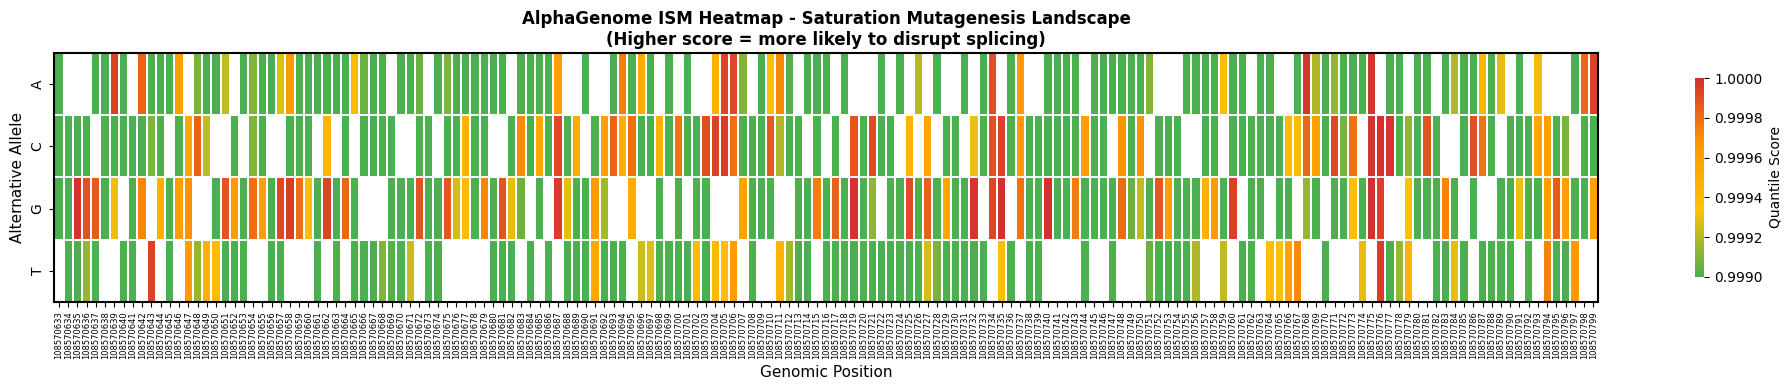

In [46]:
# Plot 1: ISM Heatmap (Saturation Mutagenesis Landscape)
plot_ism_heatmap(summary_df, OUTPUT_DIR)

Saved: score_distribution.png/svg


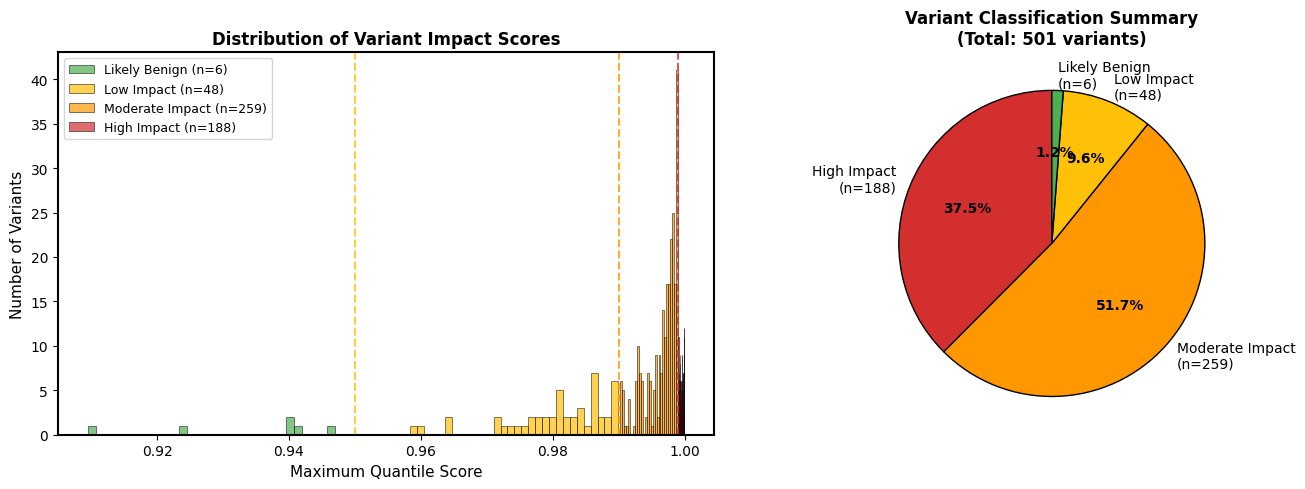

In [45]:
# Plot 2: Score Distribution
plot_score_distribution(summary_df, OUTPUT_DIR)

Saved: genomic_track.png/svg


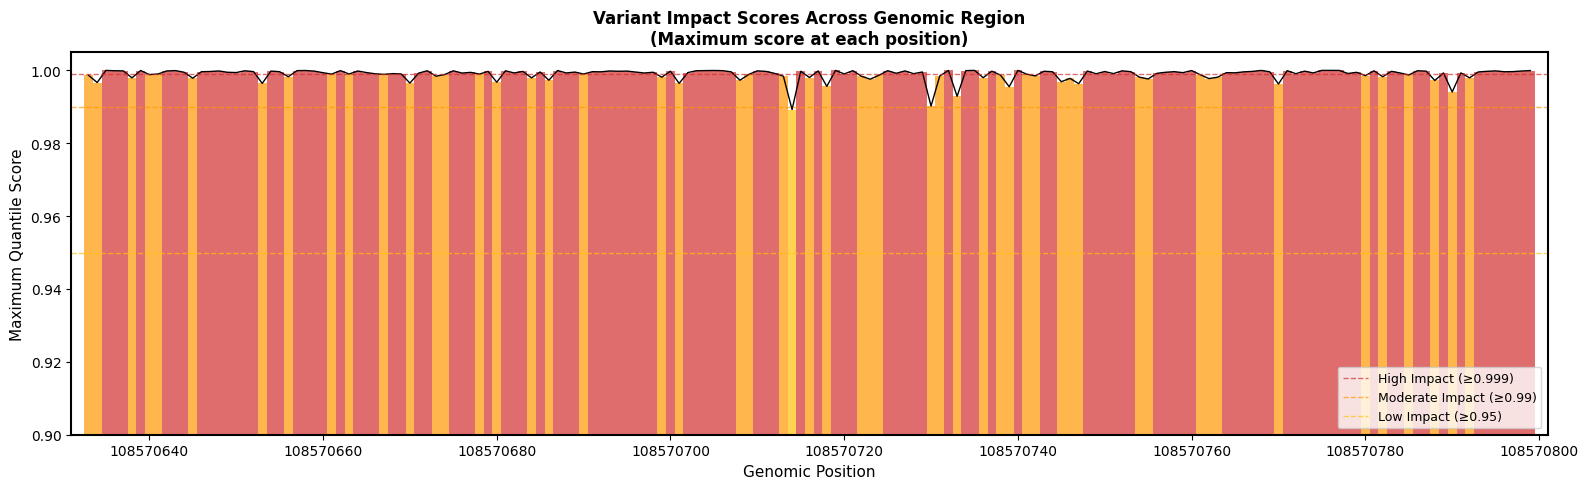

In [23]:
# Plot 3: Genomic Track
plot_genomic_track(summary_df, OUTPUT_DIR)

Saved: position_impact_summary.png/svg


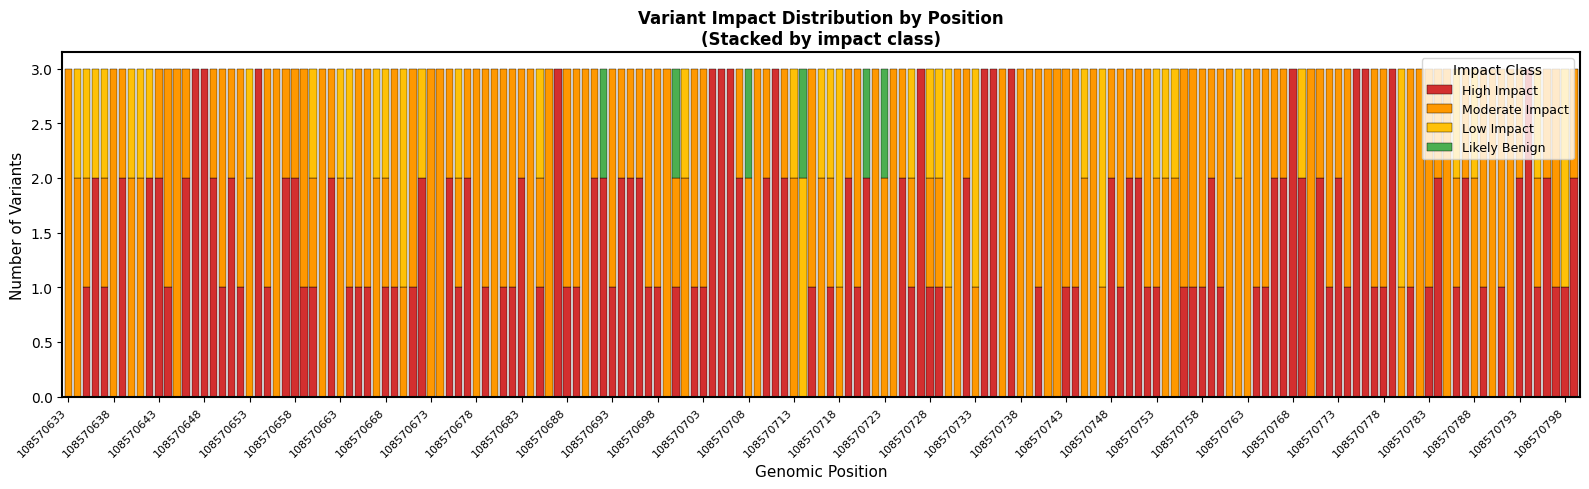

In [17]:
# Plot 4: Position Impact Summary
plot_position_impact_summary(summary_df, OUTPUT_DIR)

In [24]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import os

def plot_genomic_positions(summary_df: pd.DataFrame, output_dir: str = None):
    """
    Create separate lollipop plots for each impact class.
    Variants at the same position are aligned together with small offsets.
    Labels shown only for Low Impact variants.
    
    Parameters
    ----------
    summary_df : pd.DataFrame
        Variant summary dataframe with columns: position, change, overall_max_quantile, impact_class
    output_dir : str, optional
        Output directory for saving plots
    """
    impact_colors = {
        'High Impact': '#D32F2F',
        'Moderate Impact': '#FF9800',
        'Low Impact': '#4CAF50'
    }
    
    # Filter for the three main impact classes
    impact_classes = ['High Impact', 'Moderate Impact', 'Low Impact']
    
    figures = {}
    
    for impact_class in impact_classes:
        # Filter data for this impact class
        class_df = summary_df[summary_df['impact_class'] == impact_class].copy()
        
        if len(class_df) == 0:
            print(f"No variants found for {impact_class}")
            continue
        
        # Sort by position and change
        plot_df = class_df.sort_values(['position', 'change']).reset_index(drop=True)
        
        # For variants at same position, add small horizontal offset
        plot_df['pos_count'] = plot_df.groupby('position').cumcount()
        plot_df['pos_total'] = plot_df.groupby('position')['position'].transform('count')
        
        # Small offset (1.5 bp) for variants at same position, centered
        plot_df['x_plot'] = plot_df['position'] + (plot_df['pos_count'] - (plot_df['pos_total']-1)/2) * 1.5
        
        # Vertical staggering for labels to prevent overlap (only needed for Low Impact)
        plot_df['label_y_offset'] = plot_df['pos_count'] * 0.004
        
        # Create figure
        fig, ax = plt.subplots(figsize=(14, 7))
        
        color = impact_colors[impact_class]
        
        # Determine if we show labels for this impact class
        show_labels = (impact_class == 'Low Impact')
        
        # Plot lollipop stems and points
        for _, row in plot_df.iterrows():
            # Stem (from baseline to point)
            ax.plot([row['x_plot'], row['x_plot']], [0.9, row['overall_max_quantile']], 
                    color=color, linewidth=1.5, zorder=1)
            
            # Point
            ax.scatter(row['x_plot'], row['overall_max_quantile'], 
                       color=color, s=80, zorder=2, edgecolors='white', linewidths=0.5)
            
            # Only add labels and connectors for Low Impact
            if show_labels:
                # Label position (with vertical staggering and base offset)
                label_y = row['overall_max_quantile'] + 0.008 + row['label_y_offset']
                
                # Connector line from point to label
                ax.plot([row['x_plot'], row['x_plot']], 
                        [row['overall_max_quantile'], label_y - 0.002],
                        color='gray', linewidth=0.5, linestyle=':', alpha=0.5, zorder=1)
                
                # Label
                label_text = row.get('short_change', row['change'])
                ax.annotate(label_text, 
                            xy=(row['x_plot'], label_y),
                            ha='center', va='bottom',
                            fontsize=8, color=color, fontweight='bold')
        
        # Add threshold lines
        ax.axhline(y=0.999, color='#D32F2F', linestyle='--', alpha=0.5, linewidth=1, zorder=0)
        ax.axhline(y=0.99, color='#FF9800', linestyle='--', alpha=0.5, linewidth=1, zorder=0)
        
        # Set axis properties
        ax.set_xlabel('Genomic Position', fontsize=11, fontweight='bold')
        ax.set_ylabel('Maximum Quantile Score', fontsize=11, fontweight='bold')
        ax.set_title(f'{impact_class} Variants - Impact Scores Along Genomic Region\nGenomic positions with nucleotide changes labeled', 
                     fontsize=13, fontweight='bold', pad=15)
        
        # Y-axis - adjust upper limit based on whether labels are shown
        y_upper = 1.02 if show_labels else 1.005
        ax.set_ylim(0.9, y_upper)
        ax.set_yticks([0.90, 0.95, 0.99, 0.999, 1.0])
        
        # X-axis: use actual genomic positions
        unique_positions = sorted(plot_df['position'].unique())
        ax.set_xticks(unique_positions)
        ax.set_xticklabels([f"{p:,}" for p in unique_positions], rotation=90, ha='right', fontsize=8)
        
        # Set x limits with padding
        x_min = plot_df['x_plot'].min() - 5
        x_max = plot_df['x_plot'].max() + 5
        ax.set_xlim(x_min, x_max)
        
        # BLACK BORDER
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('black')
            spine.set_linewidth(1.5)
        
        # NO GRID - white background
        ax.grid(False)
        ax.set_facecolor('white')
        fig.patch.set_facecolor('white')
        
        # Add simple legend showing the impact class
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=impact_class),
        ]
        ax.legend(handles=legend_elements, loc='upper right', 
                  fontsize=10, frameon=True, fancybox=False, edgecolor='black')
        
        plt.tight_layout()
        
        # Save with impact class in filename
        if output_dir:
            os.makedirs(output_dir, exist_ok=True)
            filename_base = impact_class.lower().replace(' ', '_')
            plt.savefig(os.path.join(output_dir, f'variant_genomic_positions_{filename_base}.png'), 
                       dpi=300, bbox_inches='tight')
            plt.savefig(os.path.join(output_dir, f'variant_genomic_positions_{filename_base}.svg'), 
                       bbox_inches='tight')
            print(f"Saved: variant_genomic_positions_{filename_base}.png/svg")
        
        figures[impact_class] = fig
        plt.show()
        plt.close()
    
    return figures

Saved: variant_genomic_positions_high_impact.png/svg


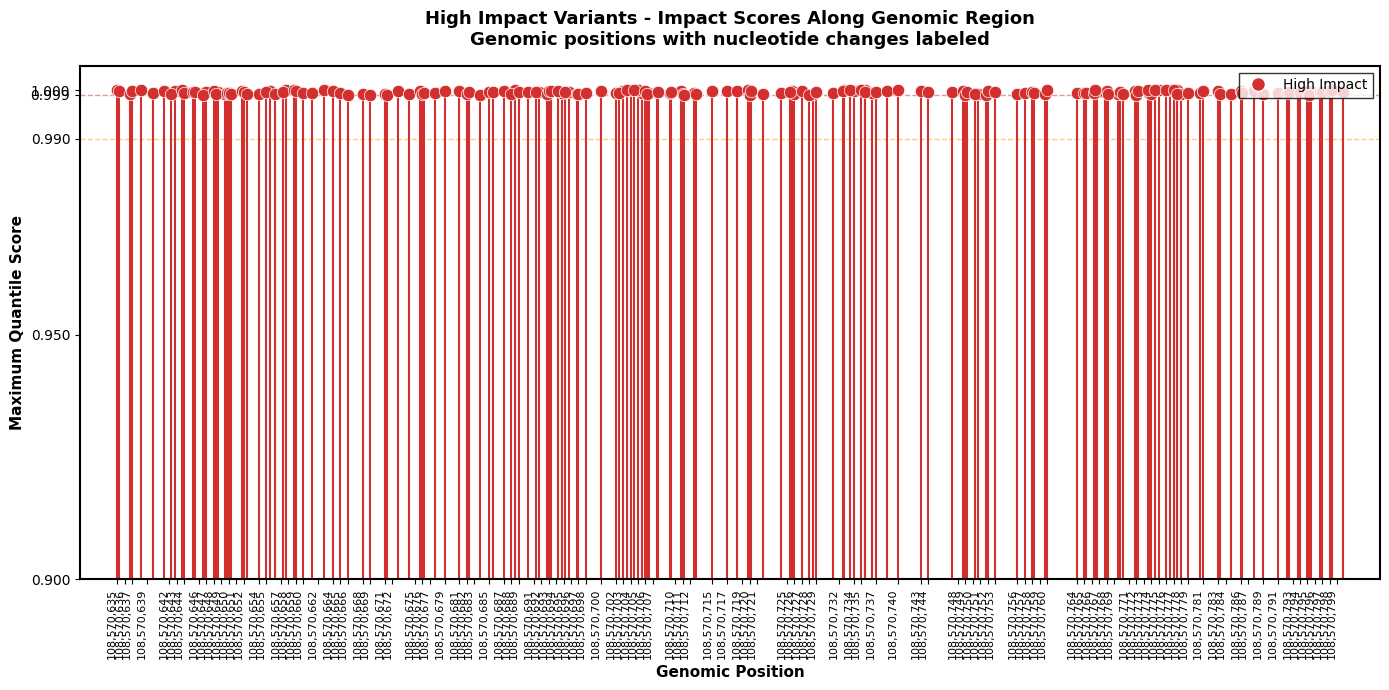

Saved: variant_genomic_positions_moderate_impact.png/svg


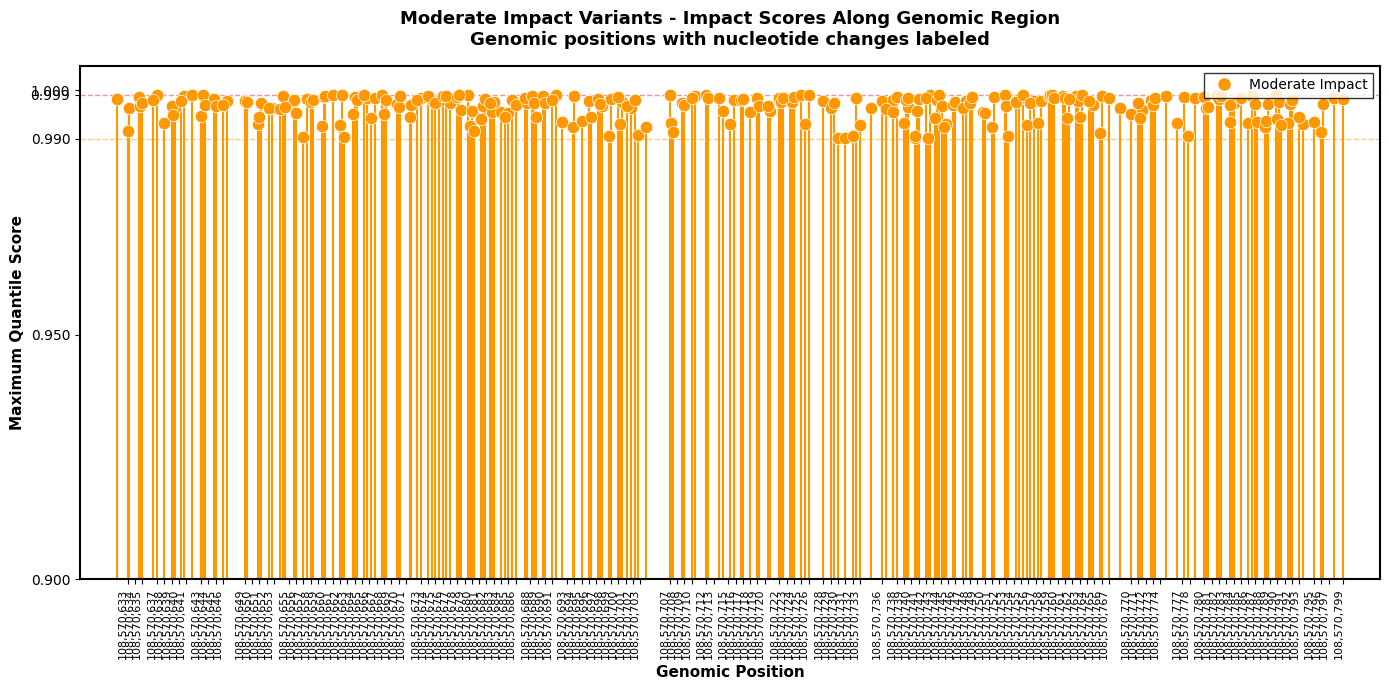

Saved: variant_genomic_positions_low_impact.png/svg


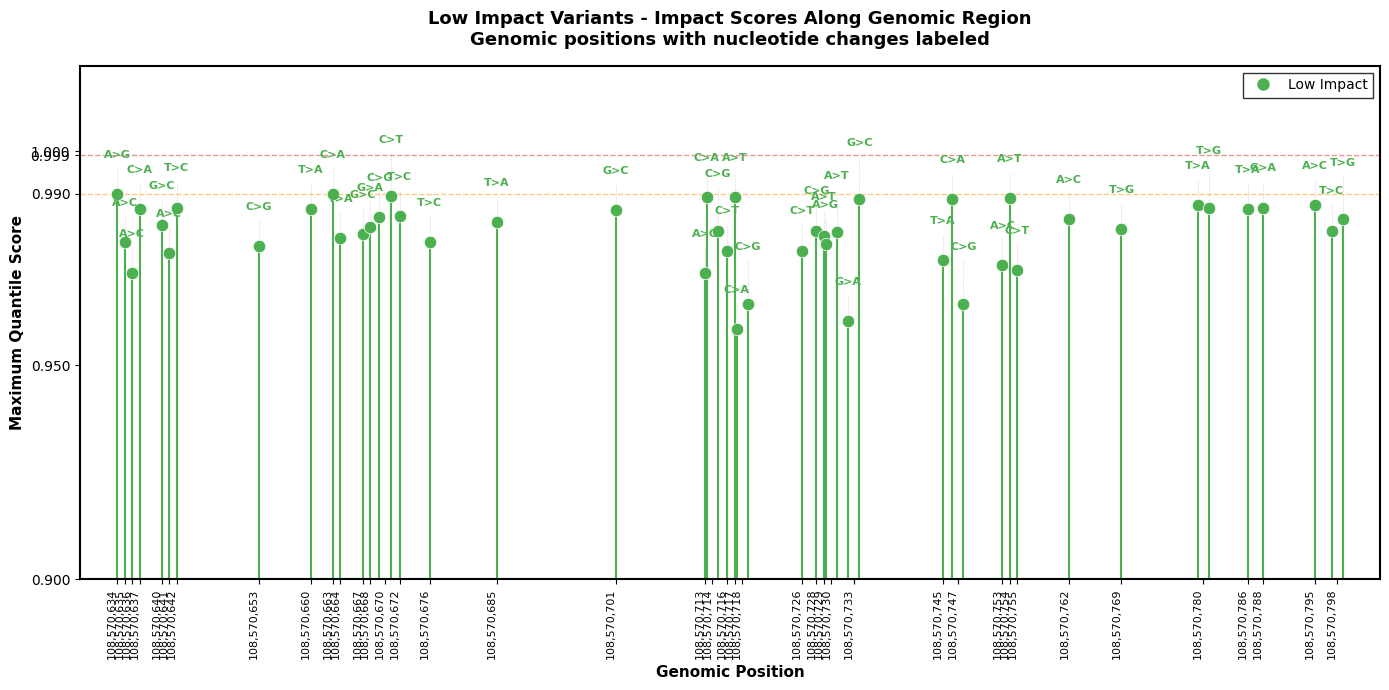

In [25]:
figures = plot_genomic_positions(summary_df, output_dir='output_plots')

### 8.5 Save Results

In [ ]:
# Save summary table
final_summary = save_summary_table(summary_df, OUTPUT_DIR)

print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)
print(f"\nOutput files saved to: {OUTPUT_DIR}")
print("  - ism_variant_summary.csv")
print("  - ism_heatmap.png/svg")
print("  - score_distribution.png/svg")
print("  - genomic_track.png/svg")
print("  - position_impact_summary.png/svg")

---
## 9. Interpretation Guide

### Understanding the Results

**Quantile Scores:**
- Scores range from 0 to 1
- Higher scores indicate stronger predicted effects on splicing
- A score of 0.999 means the variant has a stronger effect than 99.9% of all possible variants

**Impact Classification:**
- **High Impact (≥0.999)**: Top 0.1% - Very likely to disrupt splicing
- **Moderate Impact (≥0.99)**: Top 1% - Likely to affect splicing
- **Low Impact (≥0.95)**: Top 5% - May have minor effects
- **Likely Benign (<0.95)**: Below top 5% - Unlikely to significantly affect splicing

**Key Visualizations:**
1. **ISM Heatmap**: Shows the complete saturation mutagenesis landscape. Hotspots (red regions) indicate positions where mutations are most likely to disrupt splicing.
2. **Score Distribution**: Shows how variants are distributed across impact classes.
3. **Genomic Track**: Highlights positions with the highest impact scores.
4. **Position Impact Summary**: Shows how many high/moderate/low impact variants exist at each position.